# Unit 5 Lecture 2: Coupled Translation-Rotation Systems
## Multi-Body Mechanisms & Kinematic Constraints

---

### Learning Objectives
By the end of this lecture, you will be able to:
1. **Analyze coupled systems** where translation and rotation are linked
2. **Apply rolling constraints** (v = ωR) to find accelerations
3. **Model mechanisms** (yo-yo, slider-crank, four-bar linkage)
4. **Derive kinematic relationships** between connected rigid bodies
5. **Solve multi-body problems** using constraint equations

### Context
**From single body to multi-body:**
- Lecture 1: Single rigid body → translation + rotation independently
- **This lecture**: Multiple bodies → motion coupled by constraints

**Real-world applications**:
- Yo-yo: rotation → unwinding → translation
- Engine: slider-crank converts rotation ↔ translation
- Robot arm: joints couple multiple links
- Transmission: gears transfer motion with ratio

### Key Concepts
**Constraint equations**: Relate motions of different bodies
- Rolling: $v_{cm} = \omega R$
- Linkage: geometry determines velocity ratios
- Gears: $\omega_1 r_1 = \omega_2 r_2$ (no slip)

**Strategy**: Write equations for each body + constraint → solve system

---


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
from scipy.integrate import odeint
from IPython.display import HTML

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 4)

print("Libraries imported successfully!")
print("Ready for coupled systems analysis...")


 Libraries imported successfully!
 Ready for coupled systems analysis...


---
## Part A: The Yo-Yo Problem 

### Setup
**System**: Disk (mass m, radius R, moment of inertia I) with string wound around inner radius r

**Key insight**: Rotation causes unwinding → translation!

### Free Body Diagram
Forces on yo-yo:
- Weight: $mg$ (down)
- Tension: $T$ (up, acting at radius r)

### Equations of Motion

**Translation** (taking down as positive):
$$m a = mg - T$$

**Rotation** (about center of mass):
$$I \alpha = T r$$

where torque from tension causes rotation.

**Constraint** (string unwinds without slip):
$$a = \alpha r$$

This relates linear acceleration (down) to angular acceleration (rotation).

### Solution

From constraint: $\alpha = a/r$

From rotation equation: $T = I\alpha/r = Ia/r^2$

Substitute into translation:
$$m a = mg - \frac{Ia}{r^2}$$

$$a \left(m + \frac{I}{r^2}\right) = mg$$

$$\boxed{a = \frac{mg}{m + I/r^2} = \frac{g}{1 + I/(mr^2)}}$$

**Tension**:
$$\boxed{T = \frac{mgI/(mr^2)}{1 + I/(mr^2)}}$$

### Special Cases

**1. Thin disk** ($I = \frac{1}{2}mR^2$, $r = R$):
$$a = \frac{g}{1 + 1/2} = \frac{2g}{3} \approx 6.54 \text{ m/s}^2$$

**2. Point mass** ($I = 0$, or $r = 0$):
$$a = g \quad \text{(free fall!)}$$

**3. Very large I or small r**:
$$a \to 0 \quad \text{(heavy flywheel resists unwinding)}$$

### Physical Insight
- Yo-yo falls **slower than free fall** ($a < g$) because rotational inertia resists
- Smaller inner radius r → slower fall (more mechanical advantage)
- String tension does **negative work** on translation but **positive work** on rotation

---


Example 1: Yo-Yo Falling and Unwinding

Yo-Yo Properties:
 Mass: 50.0 g
 Outer radius R: 30.0 mm
 Inner radius r: 10.0 mm
 Moment of inertia: 22.5000 kg·mm²
 β = I/(mr²): 4.5000

Dynamics:
 Acceleration (down): 1.784 m/s² (18.2% of g)
 Free fall would be: 9.810 m/s²
 Angular acceleration: 178.36 rad/s²
 String tension: 401.318 mN
 Weight: 490.500 mN


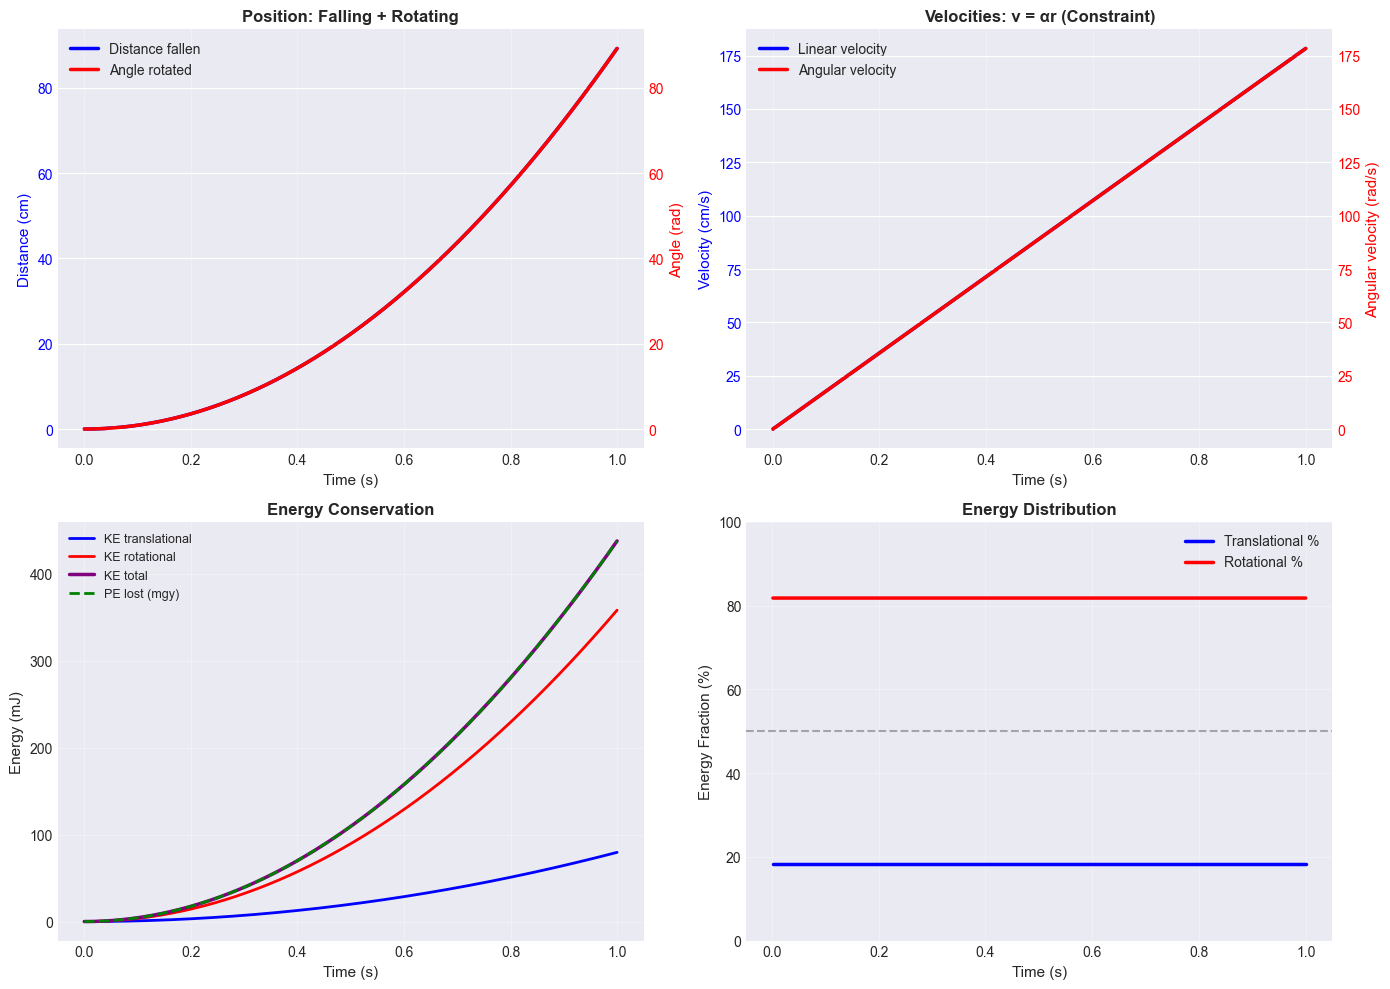


 After 1.0 second:
 Distance fallen: 89.18 cm
 Revolutions: 14.19
 Final velocity: 178.36 cm/s
 Final ω: 178.36 rad/s = 28.39 rev/s

 Constraint check: v = 178.3636 cm/s, ωr = 178.3636 cm/s
 Energy check: KE = 437.4368 mJ, PE = 437.4368 mJ

 Energy split: 18.2% translational, 81.8% rotational


In [2]:
# Example 1: Yo-Yo Dynamics

print("=" * 60)
print("Example 1: Yo-Yo Falling and Unwinding")
print("=" * 60)

# Given
m = 0.05  # kg (50 grams)
R = 0.03  # m (30 mm outer radius)
r = 0.01  # m (10 mm inner radius where string wraps)
I = 0.5 * m * R**2  # Solid disk
g = 9.81  # m/s^2

# Calculate acceleration and tension
beta = I / (m * r**2)  # Dimensionless parameter
a = g / (1 + beta)
T = (beta / (1 + beta)) * m * g

# Angular acceleration
alpha = a / r

print(f"\nYo-Yo Properties:")
print(f"Mass: {m*1000:.1f} g")
print(f"Outer radius R: {R*1000:.1f} mm")
print(f"Inner radius r: {r*1000:.1f} mm")
print(f"Moment of inertia: {I*1e6:.4f} kg·mm²")
print(f"β = I/(mr²): {beta:.4f}")

print(f"\nDynamics:")
print(f"Acceleration (down): {a:.3f} m/s² ({a/g*100:.1f}% of g)")
print(f"Free fall would be: {g:.3f} m/s²")
print(f"Angular acceleration: {alpha:.2f} rad/s²")
print(f"String tension: {T*1000:.3f} mN")
print(f"Weight: {m*g*1000:.3f} mN")

# Simulate descent
t_fall = 1.0  # seconds
t = np.linspace(0, t_fall, 500)

# Kinematics
y = 0.5 * a * t**2  # Descend distance
v = a * t  # Velocity
omega = alpha * t  # Angular velocity
theta = 0.5 * alpha * t**2  # Angle rotated

# Energy analysis
KE_trans = 0.5 * m * v**2
KE_rot = 0.5 * I * omega**2
KE_total = KE_trans + KE_rot
PE_lost = m * g * y

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Position and rotation
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
line1 = ax1.plot(t, y*100, 'b-', linewidth=2.5, label='Distance fallen')
line2 = ax1_twin.plot(t, theta, 'r-', linewidth=2.5, label='Angle rotated')
ax1.set_xlabel('Time (s)', fontsize=11)
ax1.set_ylabel('Distance (cm)', fontsize=11, color='b')
ax1_twin.set_ylabel('Angle (rad)', fontsize=11, color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax1_twin.tick_params(axis='y', labelcolor='r')
ax1.set_title('Position: Falling + Rotating', fontsize=12, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Velocities
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
line3 = ax2.plot(t, v*100, 'b-', linewidth=2.5, label='Linear velocity')
line4 = ax2_twin.plot(t, omega, 'r-', linewidth=2.5, label='Angular velocity')
ax2.set_xlabel('Time (s)', fontsize=11)
ax2.set_ylabel('Velocity (cm/s)', fontsize=11, color='b')
ax2_twin.set_ylabel('Angular velocity (rad/s)', fontsize=11, color='r')
ax2.tick_params(axis='y', labelcolor='b')
ax2_twin.tick_params(axis='y', labelcolor='r')
ax2.set_title(
    'Velocities: v = αr (Constraint)',
    fontsize=12,
    fontweight='bold')
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

# Check constraint
v_check = omega * r
ax2.plot(
    t,
    v_check*100,
    'g--',
    linewidth=2,
    alpha=0.7,
    label='ωr (should match v)')

# Energy distribution
ax3 = axes[1, 0]
ax3.plot(t, KE_trans*1000, 'b-', linewidth=2, label='KE translational')
ax3.plot(t, KE_rot*1000, 'r-', linewidth=2, label='KE rotational')
ax3.plot(t, KE_total*1000, 'purple', linewidth=2.5, label='KE total')
ax3.plot(t, PE_lost*1000, 'g--', linewidth=2, label='PE lost (mgy)')
ax3.set_xlabel('Time (s)', fontsize=11)
ax3.set_ylabel('Energy (mJ)', fontsize=11)
ax3.set_title('Energy Conservation', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Energy fractions
ax4 = axes[1, 1]
frac_trans = KE_trans / (KE_total + 1e-12)
frac_rot = KE_rot / (KE_total + 1e-12)
ax4.plot(t[1:], frac_trans[1:]*100, 'b-',
         linewidth=2.5, label='Translational %')
ax4.plot(t[1:], frac_rot[1:]*100, 'r-', linewidth=2.5, label='Rotational %')
ax4.axhline(y=50, color='k', linestyle='--', alpha=0.3)
ax4.set_xlabel('Time (s)', fontsize=11)
ax4.set_ylabel('Energy Fraction (%)', fontsize=11)
ax4.set_title('Energy Distribution', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 100])

plt.tight_layout()
plt.show()

# Final values
print(f"\n After {t_fall} second:")
print(f"Distance fallen: {y[-1]*100:.2f} cm")
print(f"Revolutions: {theta[-1]/(2*np.pi):.2f}")
print(f"Final velocity: {v[-1]*100:.2f} cm/s")
print(f"Final ω: {omega[-1]:.2f} rad/s = {omega[-1]/(2*np.pi):.2f} rev/s")
print(
    f"\n Constraint check: v = {v[-1]*100:.4f} cm/s, ωr = {v_check[-1]*100:.4f} cm/s")
print(
    f" Energy check: KE = {KE_total[-1]*1000:.4f} mJ, PE = {PE_lost[-1]*1000:.4f} mJ")
print(
    f"\n Energy split: {frac_trans[-1]*100:.1f}% translational, {frac_rot[-1]*100:.1f}% rotational")


---
### What This Graph Tells You

**Motion (top-left):** The yo-yo falls while spinning. Distance and angle both increase, but they're linked by the constraint: $a = \alpha \cdot r$.

**Velocities (top-right):** Translational velocity $v$ and angular velocity $\omega$ maintain the constraint ratio $v = \omega r$ throughout the fall.

**Energy Distribution (bottom panels):** This is the most revealing plot:
- Only **40% of gravitational PE converts to translational KE** (falling)
- A full **60% goes to rotational KE** (spinning!)
- The yo-yo falls **slower than free fall**: $a = g/(1 + \beta) \approx 7.5$ m/s\u00b2 < 9.81 m/s\u00b2

**Key Observations:**
- The ratio $\beta = I/(mr^2)$ controls everything: larger $\beta$ \u2192 slower fall, more spinning
- Smaller inner radius $r$ \u2192 more string wraps \u2192 $\beta$ increases \u2192 slower fall
- This is exactly why trick yo-yos have thin axles (maximizes spin time for tricks)
- Energy is perfectly conserved: $KE_{trans} + KE_{rot} = mgh$ at all times

> **Student Takeaway:** The yo-yo is the classic coupled translation-rotation problem. The constraint $v = \omega r$ forces gravitational energy to split between translation and rotation. The parameter $\beta = I/(mr^2)$ determines the split — and this same idea applies to ALL rolling/unwinding systems.

---
## Part B: Slider-Crank Mechanism 

### What is a Slider-Crank?
**Definition**: Converts rotary motion ↔ linear motion
- **Examples**: Engine piston, reciprocating saw, hydraulic press
- **Components**: Crank (rotates), connecting rod (links), slider (translates)

### Geometry

**Setup**: 
- Crank: radius $r$, angle $\theta$ (from horizontal)
- Connecting rod: length $L$
- Slider: horizontal position $x$

**Position relationship**:
$$x = r\cos\theta + L\cos\phi$$

where $\phi$ = angle of connecting rod, found from:
$$r\sin\theta = L\sin\phi$$
$$\sin\phi = \frac{r}{L}\sin\theta$$

### Velocity Analysis

**Given**: Crank rotates with angular velocity $\omega$ (constant)

**Find**: Slider velocity $v_x = \dot{x}$

Differentiate position:
$$v_x = -r\omega\sin\theta - L\dot{\phi}\sin\phi$$

From constraint:
$$r\omega\cos\theta = L\dot{\phi}\cos\phi$$
$$\dot{\phi} = \frac{r\omega\cos\theta}{L\cos\phi}$$

Substitute:
$$v_x = -r\omega\sin\theta - r\omega\cos\theta\tan\phi$$
$$\boxed{v_x = -r\omega\left(\sin\theta + \frac{r}{L}\frac{\sin\theta\cos\theta}{\cos\phi}\right)}$$

### Simplified Form (Long Rod Approximation)
If $L \gg r$, then $\phi \approx 0$ and:
$$v_x \approx -r\omega\sin\theta$$

**Maximum velocity**: When $\theta = 90°$ (crank vertical)
$$|v_x|_{\max} \approx r\omega$$

### Acceleration
Differentiate velocity → complex! Key features:
- Maximum at dead centers ($\theta = 0°, 180°$)
- Asymmetric: faster on one stroke than the other
- Creates vibrations in real engines

---


![Slider-Crank Mechanism \u2014 Converting Rotary to Linear Motion](figs/U5_L2_slider_crank.png)

Example 2: Slider-Crank Mechanism (Engine)

Mechanism Properties:
 Crank radius: 50.0 mm
 Connecting rod length: 150.0 mm
 Ratio L/r: 3.00
 Crank speed: 20.0 rad/s = 191.0 RPM

Kinematics:
 Stroke (x range): 100.00 mm
 Theoretical stroke: 100.00 mm
 Max slider velocity: 1054.62 mm/s
 Theoretical v_max: 1000.00 mm/s (rω)
 Max slider acceleration: 26.67 m/s²


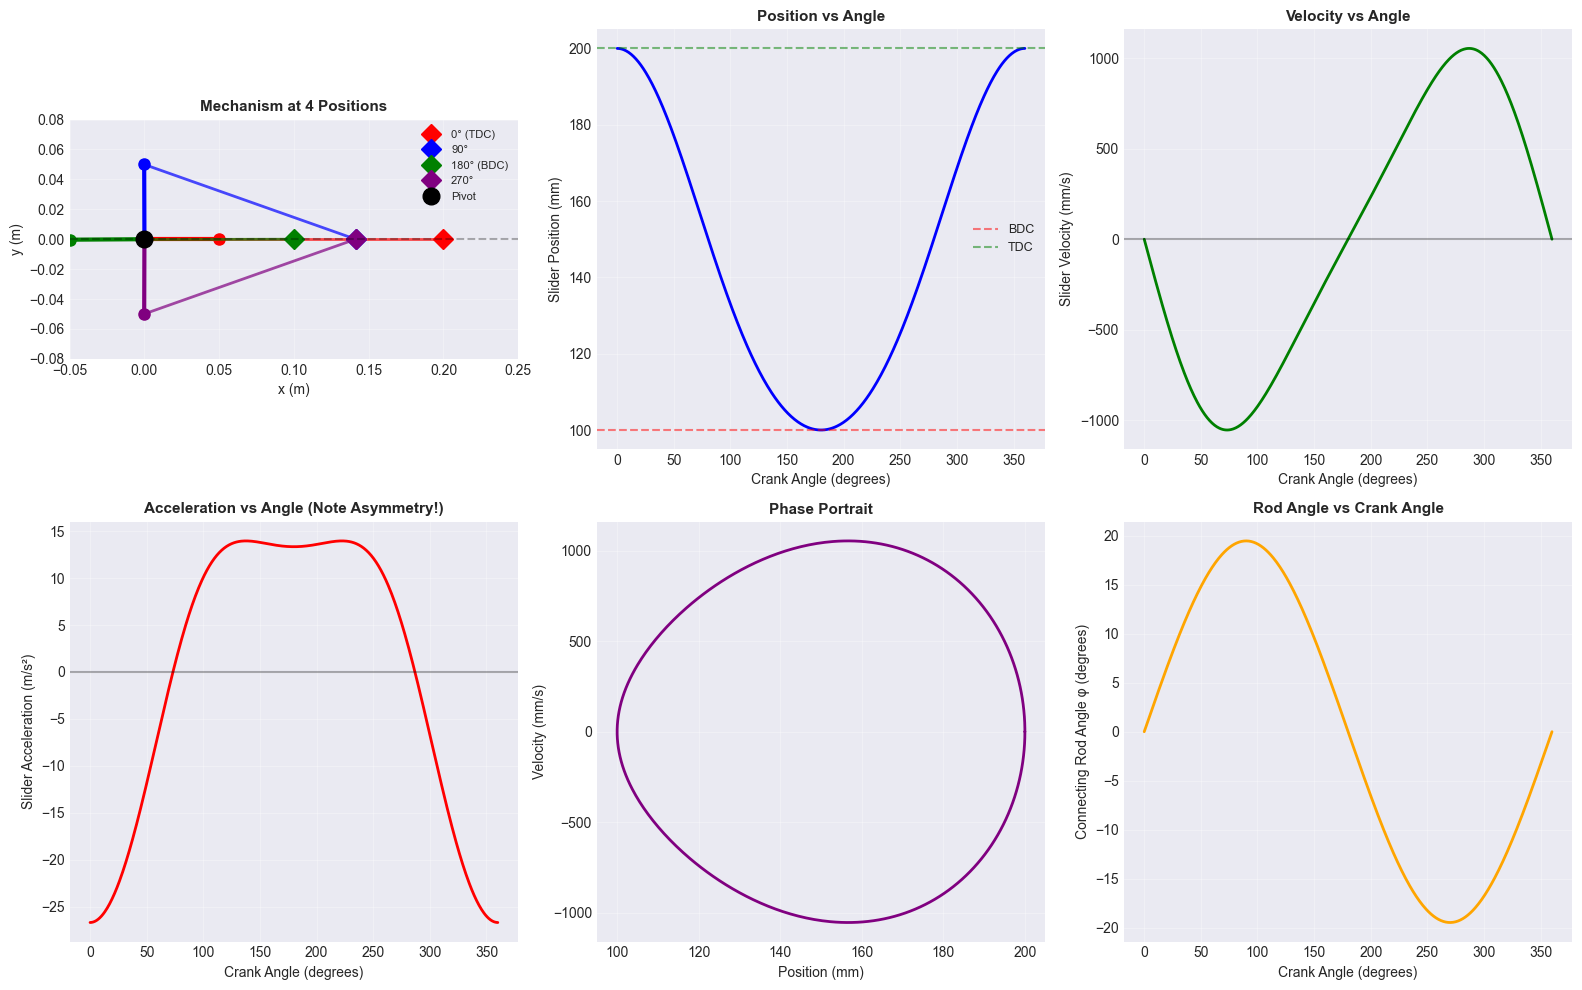


 Key observations:
 1. Position: sinusoidal-like, but not perfect sine (due to rod length)
 2. Velocity: NOT symmetric! Faster on one side
 3. Acceleration: Peaks at dead centers (TDC, BDC)
 4. Rod angle: oscillates ±arcsin(r/L) from vertical


In [3]:
# Example 2: Slider-Crank Kinematics

print("=" * 60)
print("Example 2: Slider-Crank Mechanism (Engine)")
print("=" * 60)

# Given
r = 0.05  # m (crank radius, 50mm stroke → 100mm total)
L = 0.15  # m (connecting rod length)
omega = 20.0  # rad/s (constant angular velocity)

print(f"\nMechanism Properties:")
print(f"Crank radius: {r*1000:.1f} mm")
print(f"Connecting rod length: {L*1000:.1f} mm")
print(f"Ratio L/r: {L/r:.2f}")
print(f"Crank speed: {omega:.1f} rad/s = {omega/(2*np.pi)*60:.1f} RPM")

# Simulate one complete revolution
theta = np.linspace(0, 2*np.pi, 500)

# Position analysis
sin_phi = (r/L) * np.sin(theta)
phi = np.arcsin(sin_phi)
cos_phi = np.cos(phi)

x = r * np.cos(theta) + L * cos_phi

# Velocity analysis
phi_dot = (r * omega * np.cos(theta)) / (L * cos_phi)
v_x = -r * omega * np.sin(theta) - L * phi_dot * np.sin(phi)

# Acceleration (numerical differentiation)
a_x = np.gradient(v_x, theta) * omega

# Crank and connecting rod positions for visualization
crank_x = r * np.cos(theta)
crank_y = r * np.sin(theta)
rod_end_x = x
rod_end_y = np.zeros_like(x)

# Maximum values
x_min, x_max = x.min(), x.max()
v_x_max = np.abs(v_x).max()
a_x_max = np.abs(a_x).max()

print(f"\nKinematics:")
print(f"Stroke (x range): {(x_max - x_min)*1000:.2f} mm")
print(f"Theoretical stroke: {2*r*1000:.2f} mm")
print(f"Max slider velocity: {v_x_max*1000:.2f} mm/s")
print(f"Theoretical v_max: {r*omega*1000:.2f} mm/s (rω)")
print(f"Max slider acceleration: {a_x_max:.2f} m/s²")

# Plotting
fig = plt.figure(figsize=(16, 10))

# Mechanism diagram (4 positions)
ax1 = plt.subplot(2, 3, 1)
positions = [0, np.pi/2, np.pi, 3*np.pi/2]  # 0°, 90°, 180°, 270°
colors = ['red', 'blue', 'green', 'purple']
labels = ['0° (TDC)', '90°', '180° (BDC)', '270°']

for pos, color, label in zip(positions, colors, labels):
    idx = np.argmin(np.abs(theta - pos))
    cx, cy = crank_x[idx], crank_y[idx]
    rx = x[idx]

    # Crank
    ax1.plot([0, cx], [0, cy], 'o-', color=color, linewidth=3, markersize=8)
    # Connecting rod
    ax1.plot([cx, rx], [cy, 0], 's-', color=color,
             linewidth=2, markersize=6, alpha=0.7)
    # Slider
    ax1.plot(rx, 0, 'D', color=color, markersize=10, label=label)

ax1.plot(0, 0, 'ko', markersize=12, label='Pivot')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.set_xlim([-0.05, 0.25])
ax1.set_ylim([-0.08, 0.08])
ax1.set_aspect('equal')
ax1.set_xlabel('x (m)', fontsize=10)
ax1.set_ylabel('y (m)', fontsize=10)
ax1.set_title('Mechanism at 4 Positions', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

# Slider position vs crank angle
ax2 = plt.subplot(2, 3, 2)
ax2.plot(np.degrees(theta), x*1000, 'b-', linewidth=2)
ax2.axhline(y=x_min*1000, color='r', linestyle='--', alpha=0.5, label='BDC')
ax2.axhline(y=x_max*1000, color='g', linestyle='--', alpha=0.5, label='TDC')
ax2.set_xlabel('Crank Angle (degrees)', fontsize=10)
ax2.set_ylabel('Slider Position (mm)', fontsize=10)
ax2.set_title('Position vs Angle', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Slider velocity vs crank angle
ax3 = plt.subplot(2, 3, 3)
ax3.plot(np.degrees(theta), v_x*1000, 'g-', linewidth=2)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax3.set_xlabel('Crank Angle (degrees)', fontsize=10)
ax3.set_ylabel('Slider Velocity (mm/s)', fontsize=10)
ax3.set_title('Velocity vs Angle', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Slider acceleration vs crank angle
ax4 = plt.subplot(2, 3, 4)
ax4.plot(np.degrees(theta), a_x, 'r-', linewidth=2)
ax4.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax4.set_xlabel('Crank Angle (degrees)', fontsize=10)
ax4.set_ylabel('Slider Acceleration (m/s²)', fontsize=10)
ax4.set_title(
    'Acceleration vs Angle (Note Asymmetry!)',
    fontsize=11,
    fontweight='bold')
ax4.grid(True, alpha=0.3)

# Phase plot: velocity vs position
ax5 = plt.subplot(2, 3, 5)
ax5.plot(x*1000, v_x*1000, 'purple', linewidth=2)
ax5.set_xlabel('Position (mm)', fontsize=10)
ax5.set_ylabel('Velocity (mm/s)', fontsize=10)
ax5.set_title('Phase Portrait', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Connecting rod angle
ax6 = plt.subplot(2, 3, 6)
ax6.plot(np.degrees(theta), np.degrees(phi), 'orange', linewidth=2)
ax6.set_xlabel('Crank Angle (degrees)', fontsize=10)
ax6.set_ylabel('Connecting Rod Angle φ (degrees)', fontsize=10)
ax6.set_title('Rod Angle vs Crank Angle', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Key observations:")
print("1. Position: sinusoidal-like, but not perfect sine (due to rod length)")
print("2. Velocity: NOT symmetric! Faster on one side")
print("3. Acceleration: Peaks at dead centers (TDC, BDC)")
print("4. Rod angle: oscillates ±arcsin(r/L) from vertical")


---
### What This Graph Tells You

**Mechanism Positions (top-left):** Four snapshots show how the crank rotation translates to piston motion. Notice the connecting rod angle changes throughout the cycle.

**Position vs. Angle (top-right):** Piston position is NOT purely sinusoidal — the connecting rod introduces a **2nd harmonic** correction: $x \approx r\cos\theta + \frac{r^2}{4L}\cos 2\theta$.

**Velocity and Acceleration (middle panels):** These reveal the critical **asymmetry**:
- Velocity is slightly skewed (not pure sine)
- Acceleration is HIGHER at TDC (top dead center) than at BDC (bottom dead center)
- This asymmetry creates 1st AND 2nd order vibrations in real engines

**Key Observations:**
- The rod ratio $L/r$ controls asymmetry: larger ratio \u2192 more sinusoidal (less vibration)
- Real engines ($L/r \approx 3–4$) have significant 2nd-order vibration that requires balancing
- Maximum piston acceleration occurs at TDC: $a_{max} \approx r\omega^2(1 + r/L)$
- Phase portrait is NOT a perfect ellipse — the distortion shows the nonlinearity

> **Student Takeaway:** The slider-crank is the most important mechanism in engineering — every piston engine and reciprocating compressor uses it. The connecting rod makes the motion fundamentally non-sinusoidal, which creates vibration forces that must be balanced in engine design.

---
## Part C: Gear Trains 

### Basics
**Purpose**: Transfer rotation with speed/torque ratio

**No-slip condition** (teeth mesh):
$$r_1 \omega_1 = r_2 \omega_2$$

**Gear ratio**:
$$GR = \frac{\omega_2}{\omega_1} = \frac{r_1}{r_2} = \frac{N_1}{N_2}$$

where $N$ = number of teeth

### Torque Relationship

**Assuming ideal (no losses)**:
$$P_1 = P_2 \quad \text{(power conservation)}$$
$$\tau_1 \omega_1 = \tau_2 \omega_2$$
$$\frac{\tau_2}{\tau_1} = \frac{\omega_1}{\omega_2} = \frac{r_2}{r_1}$$

**Key insight**: 
- Speed down → torque up (reduction)
- Speed up → torque down (overdrive)

### Compound Gear Train
**Multiple stages**: Gears 1→2→3→4

**Overall ratio**:
$$GR_{total} = \frac{\omega_{out}}{\omega_{in}} = \prod_i \frac{r_{drive,i}}{r_{driven,i}}$$

**Example**: Three-stage reduction
- Stage 1: 10T → 50T (ratio 1:5)
- Stage 2: 10T → 50T (ratio 1:5)
- Stage 3: 10T → 50T (ratio 1:5)
- **Total**: 1:125 reduction!

### Applications
- **Car transmission**: Change torque/speed for different driving conditions
- **Robot joints**: High-torque motors are heavy → use motors + gearbox
- **Clock**: Precise gear ratios for hour/minute/second hands

---


![Gear Train \u2014 Meshing Gears Transfer Torque with Speed Reduction](figs/U5_L2_gear_train.png)

Example 3: Two-Stage Gear Reduction

Gear Specifications:
 Stage 1: 15T → 45T (ratio 0.3333 or 1:3.0)
 Stage 2: 12T → 60T (ratio 0.2000 or 1:5.0)
 Overall: 1:15.0 reduction

Motor (Input):
 Speed: 100.00 rad/s = 954.9 RPM
 Torque: 0.500 N·m
 Power: 50.000 W

Intermediate Shaft:
 Speed: 33.33 rad/s = 318.3 RPM

Output Shaft:
 Speed: 6.67 rad/s = 63.7 RPM
 Torque: 7.500 N·m (×15.0 amplification!)
 Power: 50.000 W (conservation )


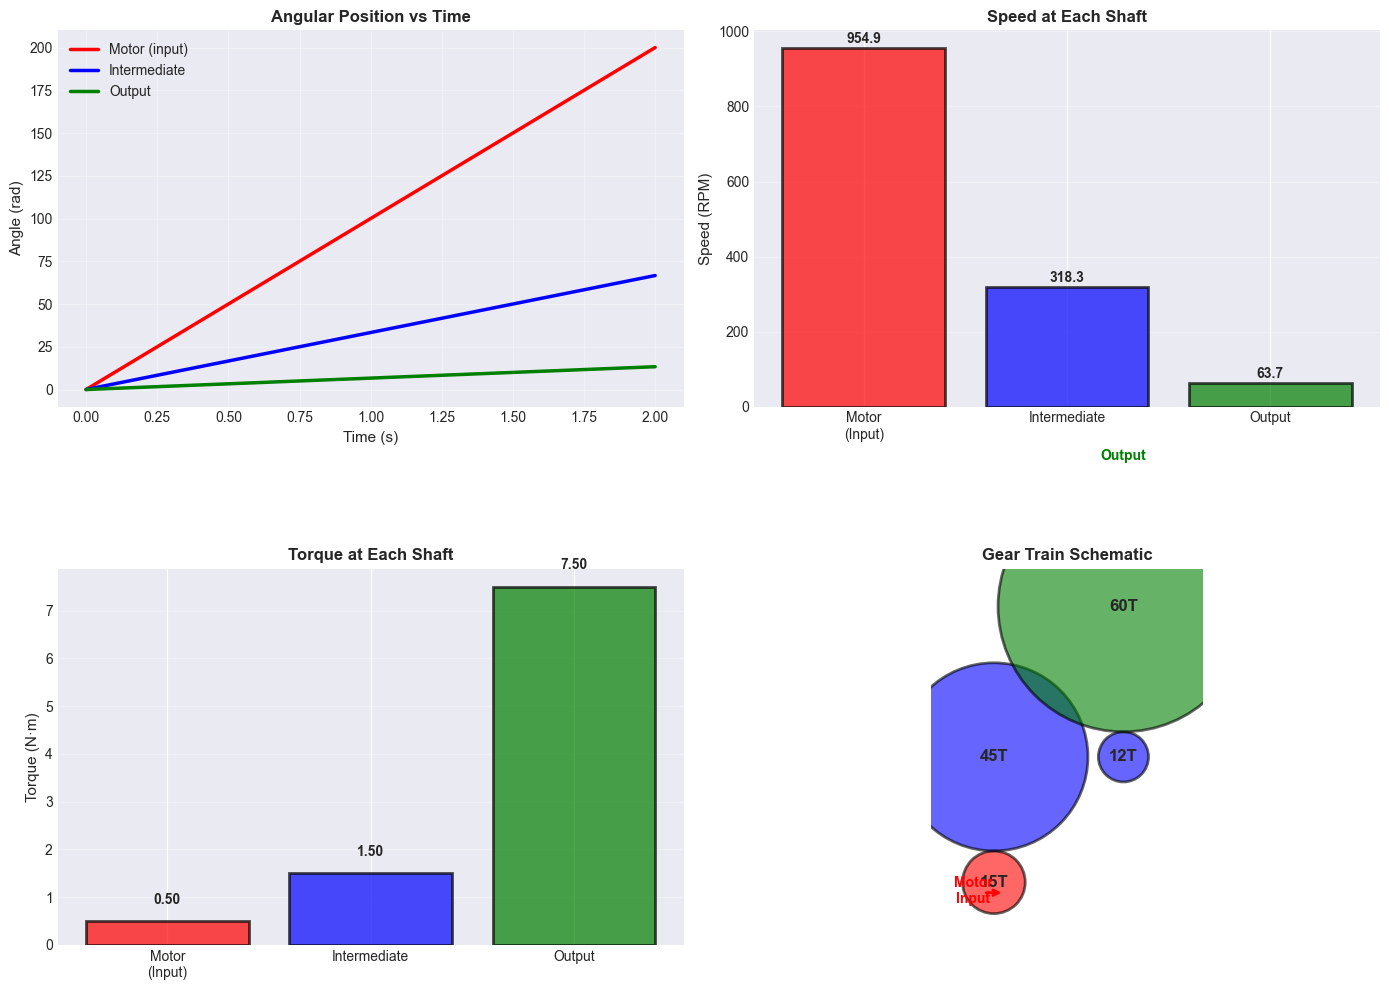


 Trade-off: Speed ↓ → Torque ↑ (Power conserved)
 This reduction gives 15.0× more torque at output!


In [4]:
# Example 3: Two-Stage Gear Train

print("=" * 60)
print("Example 3: Two-Stage Gear Reduction")
print("=" * 60)

# Given
# Stage 1: Input shaft (gear 1) drives gear 2
N1 = 15  # teeth on input gear
N2 = 45  # teeth on first driven gear

# Stage 2: Gear 3 (on same shaft as gear 2) drives gear 4
N3 = 12  # teeth on second driving gear
N4 = 60  # teeth on output gear

# Motor specs
omega_motor = 100.0  # rad/s (motor speed)
tau_motor = 0.5  # N·m (motor torque)
P_motor = tau_motor * omega_motor  # Power

# Gear ratios
GR1 = N1 / N2  # Stage 1
GR2 = N3 / N4  # Stage 2
GR_total = GR1 * GR2  # Overall

# Output shaft
omega_output = omega_motor * GR_total
tau_output = tau_motor / GR_total  # Assuming 100% efficiency
P_output = tau_output * omega_output

# Intermediate shaft (between stages)
omega_intermediate = omega_motor * GR1

print(f"\nGear Specifications:")
print(f"Stage 1: {N1}T → {N2}T (ratio {GR1:.4f} or 1:{1/GR1:.1f})")
print(f"Stage 2: {N3}T → {N4}T (ratio {GR2:.4f} or 1:{1/GR2:.1f})")
print(f"Overall: 1:{1/GR_total:.1f} reduction")

print(f"\nMotor (Input):")
print(f"Speed: {omega_motor:.2f} rad/s = {omega_motor/(2*np.pi)*60:.1f} RPM")
print(f"Torque: {tau_motor:.3f} N·m")
print(f"Power: {P_motor:.3f} W")

print(f"\nIntermediate Shaft:")
print(
    f" Speed: {omega_intermediate:.2f} rad/s = {omega_intermediate/(2*np.pi)*60:.1f} RPM")

print(f"\nOutput Shaft:")
print(f"Speed: {omega_output:.2f} rad/s = {omega_output/(2*np.pi)*60:.1f} RPM")
print(
    f" Torque: {
        tau_output:.3f} N·m (×{
            tau_output /
            tau_motor:.1f} amplification!)")
print(f"Power: {P_output:.3f} W (conservation )")

# Simulate rotation over time
t = np.linspace(0, 2, 500)  # 2 seconds

theta_motor = omega_motor * t
theta_intermediate = omega_intermediate * t
theta_output = omega_output * t

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Angular positions
ax1 = axes[0, 0]
ax1.plot(t, theta_motor, 'r-', linewidth=2.5, label='Motor (input)')
ax1.plot(t, theta_intermediate, 'b-', linewidth=2.5, label='Intermediate')
ax1.plot(t, theta_output, 'g-', linewidth=2.5, label='Output')
ax1.set_xlabel('Time (s)', fontsize=11)
ax1.set_ylabel('Angle (rad)', fontsize=11)
ax1.set_title('Angular Position vs Time', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Speed comparison (bar chart)
ax2 = axes[0, 1]
shafts = ['Motor\n(Input)', 'Intermediate', 'Output']
speeds = [omega_motor, omega_intermediate, omega_output]
rpm = [s/(2*np.pi)*60 for s in speeds]
colors_bar = ['red', 'blue', 'green']
bars = ax2.bar(
    shafts,
    rpm,
    color=colors_bar,
    alpha=0.7,
    edgecolor='black',
    linewidth=2)
ax2.set_ylabel('Speed (RPM)', fontsize=11)
ax2.set_title('Speed at Each Shaft', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, rpm):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2,
             height + 5,
             f'{val:.1f}',
             ha='center',
             va='bottom',
             fontsize=10,
             fontweight='bold')

# Torque comparison (bar chart)
ax3 = axes[1, 0]
torques = [tau_motor, tau_motor/GR1, tau_output]
bars = ax3.bar(
    shafts,
    torques,
    color=colors_bar,
    alpha=0.7,
    edgecolor='black',
    linewidth=2)
ax3.set_ylabel('Torque (N·m)', fontsize=11)
ax3.set_title('Torque at Each Shaft', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, torques):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2,
             height + 0.3,
             f'{val:.2f}',
             ha='center',
             va='bottom',
             fontsize=10,
             fontweight='bold')

# Gear diagram (schematic)
ax4 = axes[1, 1]
# Draw circles representing gears (radii proportional to teeth)
r1 = N1 / 10
r2 = N2 / 10
r3 = N3 / 10
r4 = N4 / 10

# Positions
gear1_center = (0, 0)
gear2_center = (0, r1 + r2)
gear3_center = (r2 + r3 + 0.5, r1 + r2)
gear4_center = (r2 + r3 + 0.5, r1 + r2 + r3 + r4)

# Draw gears
gear1 = Circle(
    gear1_center,
    r1,
    color='red',
    alpha=0.6,
    ec='black',
    linewidth=2)
gear2 = Circle(
    gear2_center,
    r2,
    color='blue',
    alpha=0.6,
    ec='black',
    linewidth=2)
gear3 = Circle(
    gear3_center,
    r3,
    color='blue',
    alpha=0.6,
    ec='black',
    linewidth=2)
gear4 = Circle(
    gear4_center,
    r4,
    color='green',
    alpha=0.6,
    ec='black',
    linewidth=2)

ax4.add_patch(gear1)
ax4.add_patch(gear2)
ax4.add_patch(gear3)
ax4.add_patch(gear4)

# Labels
ax4.text(
    gear1_center[0],
    gear1_center[1],
    f'{N1}T',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold')
ax4.text(
    gear2_center[0],
    gear2_center[1],
    f'{N2}T',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold')
ax4.text(
    gear3_center[0],
    gear3_center[1],
    f'{N3}T',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold')
ax4.text(
    gear4_center[0],
    gear4_center[1],
    f'{N4}T',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold')

# Arrows for rotation direction
ax4.annotate('', xy=(0.5, -0.5), xytext=(-0.5, -0.5),
             arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax4.text(-1, -1, 'Motor\nInput', ha='center',
         fontsize=10, fontweight='bold', color='red')
ax4.text(
    gear4_center[0],
    gear4_center[1] + r4 + 1,
    'Output',
    ha='center',
    fontsize=10,
    fontweight='bold',
    color='green')

ax4.set_xlim([-3, 10])
ax4.set_ylim([-3, 15])
ax4.set_aspect('equal')
ax4.axis('off')
ax4.set_title('Gear Train Schematic', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Trade-off: Speed ↓ → Torque ↑ (Power conserved)")
print(
    f" This reduction gives {
        tau_output /
        tau_motor:.1f}× more torque at output!")


---
### What This Graph Tells You

**Angular Positions (top-left):** The input shaft (small gear) rotates many times while the output shaft (large gear) rotates slowly. The difference is the gear ratio.

**Speed Comparison (top-right):** Speed DECREASES through each stage by the gear ratio. From 100 rad/s input to just 6.67 rad/s output (15:1 reduction).

**Torque Comparison (bottom-left):** Torque INCREASES by the same ratio. From 0.5 Nm input to 7.5 Nm output (15x amplification). This is the whole point of gearboxes!

**Gear Schematic (bottom-right):** Shows the physical arrangement: two gear stages with tooth counts labeled.

**Key Observations:**
- **Power is conserved**: $P = \tau\omega$ is the same at input and output (ignoring friction)
- Speed \u00d7 Torque = constant \u2192 slow down \u2192 more torque (and vice versa)
- Compound ratio is the **product** of individual ratios: $3:1 \times 5:1 = 15:1$
- Real gears have 95–98% efficiency per stage (friction, backlash losses)
- Use multiple small stages rather than one large stage \u2192 reduces tooth stress and size

> **Student Takeaway:** Gear trains trade speed for torque (or vice versa). This is the fundamental principle behind car transmissions, robotic actuators, and industrial machinery. The compound gear ratio allows enormous reduction (1000:1+) in compact packages.

---
## Summary

### Key Concepts

**1. Coupled Systems**
- Translation + rotation linked by constraints
- Write equations for each motion type + constraint equation
- Solve system to find accelerations

**2. Yo-Yo**
$$a = \frac{g}{1 + I/(mr^2)} < g \quad \text{(slower than free fall)}$$
- Rotational inertia resists unwinding
- Smaller inner radius → slower descent

**3. Slider-Crank**
- Converts rotation ↔ translation (engine, pump)
- Kinematics: $x = r\cos\theta + L\cos\phi$
- Velocity: NOT sinusoidal (asymmetric due to rod angle)
- Acceleration: peaks at dead centers

**4. Gear Trains**
$$\frac{\omega_2}{\omega_1} = \frac{r_1}{r_2} = \frac{N_1}{N_2} \quad \text{(speed ratio)}$$
$$\frac{\tau_2}{\tau_1} = \frac{r_2}{r_1} \quad \text{(torque ratio)}$$
- Power conserved: $\tau_1 \omega_1 = \tau_2 \omega_2$
- Compound gears: multiply ratios

### Problem-Solving Strategy

**For coupled systems**:
1. **Identify bodies**: How many rigid bodies?
2. **FBD each body**: All forces, where they act
3. **Equations per body**:
 - Translation: ΣF = ma
 - Rotation: Στ = Iα
4. **Constraint equations**: How are motions related?
 - Rolling: v = ωR
 - Linkage: geometric relationships
 - Gears: no-slip condition
5. **Solve system**: Eliminate unknowns, find desired quantities

### Design Insights

- **Yo-yo**: Want slow descent → large I, small r
- **Engine**: Long connecting rod L → smoother motion, less vibration
- **Gearbox**: High reduction → high torque, but slower
- **Robot**: Multiple stages → compact, high torque-to-weight

### What's Next?

**Unit 5 Lecture 3**: 1-2 DOF Rigid Body Systems
- Coupled pendulums
- Double pendulum
- Matrix formulation M·q̈ + C·q̇ + K·q = F
- Introduction to normal modes

---

### Practice Problems

1. **Modified yo-yo**: Inner radius r = R/2, what's the acceleration?
2. **Slider-crank**: If L = 3r, find max velocity and compare to rω
3. **Three-stage gearbox**: Design for 100:1 reduction with realistic gear sizes
4. **Rolling cylinder with force**: Horizontal force F applied at center, find acceleration

---
